# Regression Diagnostics in R

## Overview

Regression diagnostics evaluate whether the assumptions of a fitted model are met and whether any observations are exerting undue influence on the results. Running diagnostics is not optional — a model that violates its assumptions produces unreliable inference regardless of how significant the results look.

This notebook covers diagnostics for **linear regression** in depth, with notes on how they extend (or differ) for logistic and other GLMs.

| Diagnostic | What It Checks |
|---|---|
| Residuals vs. fitted | Linearity and homoscedasticity |
| Normal Q-Q plot | Normality of residuals |
| Scale-location plot | Homoscedasticity (spread of residuals) |
| Residuals vs. leverage | Influential observations |
| Cook's distance | Overall influence of each observation |
| VIF | Multicollinearity among predictors |
| Breusch-Pagan test | Formal test for heteroscedasticity |
| Shapiro-Wilk test | Formal test for non-normality of residuals |

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Are residuals from an invertebrate density model randomly distributed, or is there spatial autocorrelation? Does a single outlier site drive a significant treatment effect? |
| **Healthcare** | Does a linear model for blood pressure have equal variance across predicted values, or does variance increase for high-risk patients? |
| **Finance** | Are residuals from a pricing model homoscedastic, or does prediction error increase for high-value transactions? |
| **Insurance** | Are there influential policyholders driving a claims model, and do results hold if they are excluded? |

---

## Setup

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
library(tidyverse)
library(ggplot2)
library(car)          # VIF, Bonferroni outlier test, ncvTest
library(performance)  # check_model, check_heteroscedasticity
library(lmtest)       # Breusch-Pagan test
library(broom)        # augment() for tidy residuals
library(ggfortify)    # autoplot() for lm diagnostic plots in ggplot2

set.seed(42)

# ── Fit reference models ──────────────────────────────────────────────────────
# Linear model used throughout this notebook
model_lm <- lm(mpg ~ wt + hp + cyl, data = mtcars)

# Augmented data frame with residuals and influence measures
mtcars_aug <- broom::augment(model_lm, data = mtcars)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'car' was built under R version 4.4.3"
Loading required package: carData

Warning message:
"package 'carDat

---

## 1. Standard Diagnostic Plots

Base R's `plot()` on an `lm` object returns four essential diagnostic plots. These should be the first thing you examine after fitting any linear model.

ggfortify::autoplot failed. Falling back to manual ggplot2 plots.



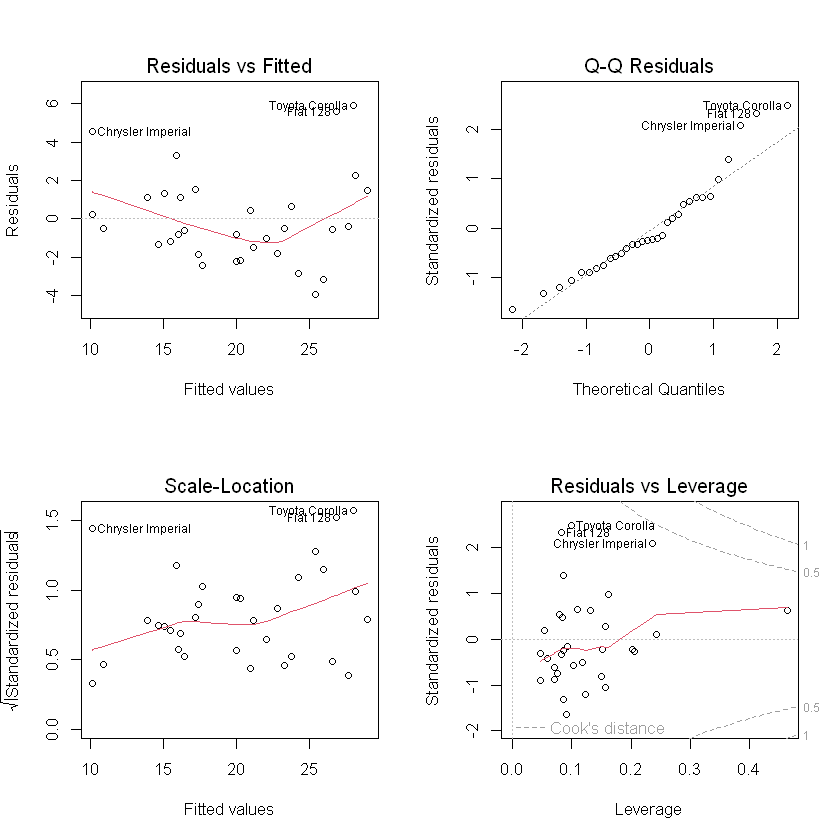

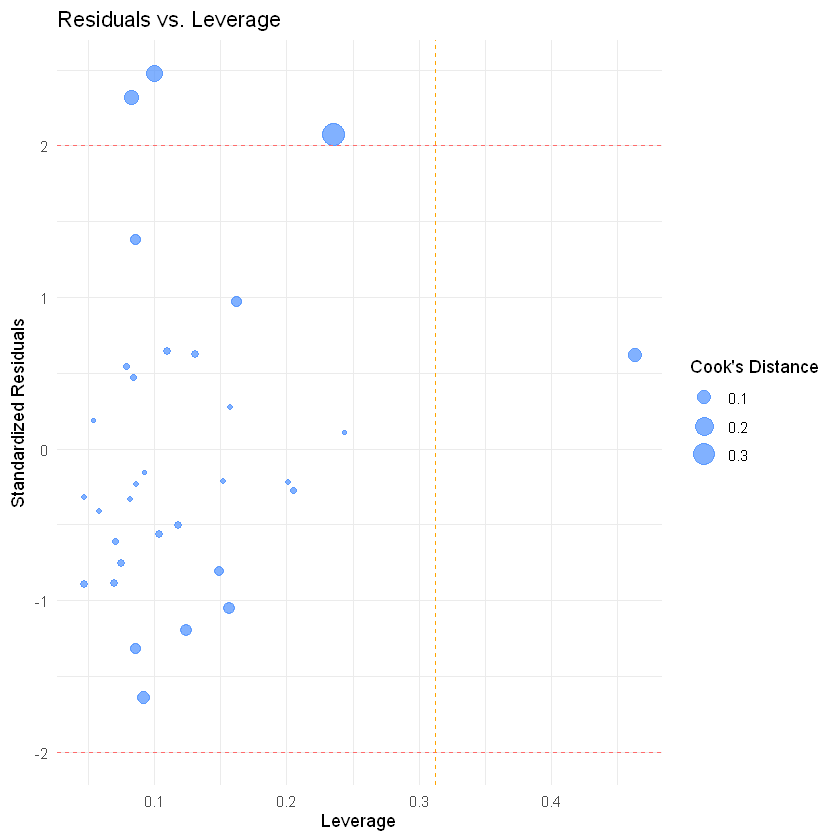

In [3]:
# ── Base R: four diagnostic plots ────────────────────────────────────────────
par(mfrow = c(2, 2))
plot(model_lm)
par(mfrow = c(1, 1))

# ── ggplot2 version (ggfortify) ───────────────────────────────────────────────
if (inherits(model_lm, "lm")) {
  tryCatch({
    ggfortify::autoplot(model_lm, which = 1:4,
                        colour = "#4a8fff",
                        smooth.colour = "#ff6b6b",
                        label.size = 3) +
      theme_minimal()
  }, error = function(e) {
    message("ggfortify::autoplot failed. Falling back to manual ggplot2 plots.")

    # Manual ggplot2 diagnostic plots
    mtcars_aug <- broom::augment(model_lm, data = mtcars)

    # Residuals vs. Fitted
    ggplot(mtcars_aug, aes(x = .fitted, y = .resid)) +
      geom_point(color = "#4a8fff", alpha = 0.7) +
      geom_smooth(method = "loess", se = FALSE, color = "#ff6b6b") +
      geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
      labs(title = "Residuals vs. Fitted",
           x = "Fitted Values", y = "Residuals") +
      theme_minimal()

    # Normal Q-Q
    ggplot(mtcars_aug, aes(sample = .resid)) +
      stat_qq(color = "#4a8fff") +
      stat_qq_line(color = "#ff6b6b") +
      labs(title = "Normal Q-Q Plot",
           x = "Theoretical Quantiles", y = "Sample Quantiles") +
      theme_minimal()

    # Scale-Location
    ggplot(mtcars_aug, aes(x = .fitted, y = sqrt(abs(.std.resid)))) +
      geom_point(color = "#4a8fff", alpha = 0.7) +
      geom_smooth(method = "loess", se = FALSE, color = "#ff6b6b") +
      labs(title = "Scale-Location Plot",
           x = "Fitted Values", y = "√|Standardized Residuals|") +
      theme_minimal()

    # Residuals vs. Leverage
    ggplot(mtcars_aug, aes(x = .hat, y = .std.resid)) +
      geom_point(aes(size = .cooksd), color = "#4a8fff", alpha = 0.7) +
      geom_hline(yintercept = c(-2, 2), linetype = "dashed", color = "#ff6b6b") +
      geom_vline(xintercept = 2 * (length(coef(model_lm)) + 1) / nrow(mtcars),
                 linetype = "dashed", color = "orange") +
      labs(title = "Residuals vs. Leverage",
           x = "Leverage", y = "Standardized Residuals",
           size = "Cook's Distance") +
      theme_minimal()
  })
} else {
  stop("model_lm is not of class 'lm'. Ensure the object is a linear model.")
}

### Reading the Four Plots

**Plot 1 — Residuals vs. Fitted:**
- ✅ Random scatter around the horizontal zero line → linearity and homoscedasticity met
- ❌ U-shaped curve → non-linearity; consider polynomial terms or GAMs
- ❌ Fan shape (spread increases with fitted values) → heteroscedasticity

**Plot 2 — Normal Q-Q:**
- ✅ Points fall along the diagonal line → normality of residuals met
- ❌ Heavy tails (S-shape) → heavier-than-normal tails
- ❌ Points curve away from line → skewed residuals

**Plot 3 — Scale-Location (Spread-Location):**
- ✅ Flat red line with equally spread points → homoscedasticity met
- ❌ Upward trend → variance increases with fitted values (heteroscedasticity)

**Plot 4 — Residuals vs. Leverage:**
- ✅ No points outside Cook's distance dashed lines → no highly influential points
- ❌ Points beyond Cook's d = 0.5 or 1.0 → potentially influential observations

---

## 2. Normality of Residuals


	Shapiro-Wilk normality test

data:  residuals(model_lm)
W = 0.93455, p-value = 0.05252


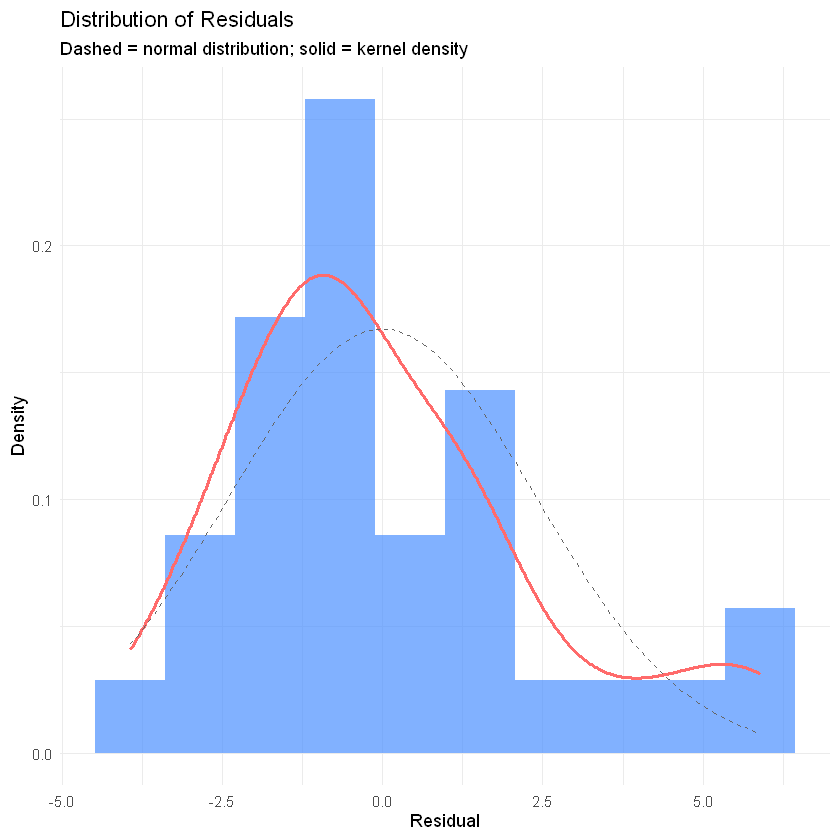

In [4]:
# ── Shapiro-Wilk test on residuals ────────────────────────────────────────────
shapiro.test(residuals(model_lm))
# p > 0.05: no evidence against normality
# Note: with large n, even minor deviations become significant
# — rely on Q-Q plot for large samples

# ── Histogram of residuals ────────────────────────────────────────────────────
ggplot(mtcars_aug, aes(x = .resid)) +
  geom_histogram(aes(y = after_stat(density)),
                 bins = 10, fill = "#4a8fff", alpha = 0.7) +
  geom_density(color = "#ff6b6b", linewidth = 1) +
  stat_function(fun = dnorm,
                args = list(mean = mean(mtcars_aug$.resid),
                            sd   = sd(mtcars_aug$.resid)),
                linetype = "dashed", color = "gray40") +
  labs(title = "Distribution of Residuals",
       subtitle = "Dashed = normal distribution; solid = kernel density",
       x = "Residual", y = "Density") +
  theme_minimal()

---

## 3. Homoscedasticity (Equal Variance)


	studentized Breusch-Pagan test

data:  model_lm
BP = 2.9351, df = 3, p-value = 0.4017


Non-constant Variance Score Test 
Variance formula: ~ fitted.values 
Chisquare = 2.882097, Df = 1, p = 0.089569

OK: Error variance appears to be homoscedastic (p = 0.090).


`geom_smooth()` using formula = 'y ~ x'


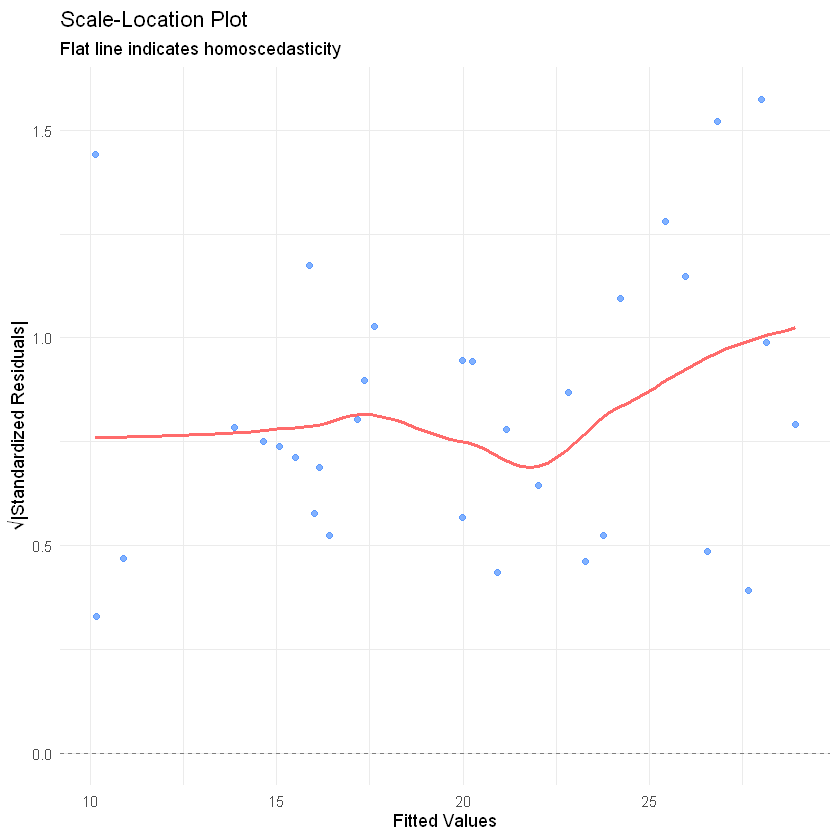

In [5]:
# ── Breusch-Pagan test ────────────────────────────────────────────────────────
lmtest::bptest(model_lm)
# H0: homoscedasticity (constant variance)
# p < 0.05: evidence of heteroscedasticity

# ── Non-constant variance score test (car) ────────────────────────────────────
car::ncvTest(model_lm)

# ── Performance package wrapper ───────────────────────────────────────────────
performance::check_heteroscedasticity(model_lm)

# ── Residuals vs. fitted: manual ggplot ───────────────────────────────────────
ggplot(mtcars_aug, aes(x = .fitted, y = sqrt(abs(.std.resid)))) +
  geom_point(color = "#4a8fff", alpha = 0.7) +
  geom_smooth(method = "loess", se = FALSE, color = "#ff6b6b") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  labs(title = "Scale-Location Plot",
       subtitle = "Flat line indicates homoscedasticity",
       x = "Fitted Values", y = "√|Standardized Residuals|") +
  theme_minimal()

# ── If heteroscedasticity is found: options ───────────────────────────────────
# 1. Log-transform the response: lm(log(y) ~ x)
# 2. Robust standard errors (sandwich estimator)
# 3. Weighted least squares

---

## 4. Multicollinearity

wt       hp      cyl 
2.580486 3.258481 4.757456

,wt,hp,cyl
wt,1.0000000,0.6587479,0.7824958
hp,0.6587479,1.0000000,0.8324475
cyl,0.7824958,0.8324475,1.0000000


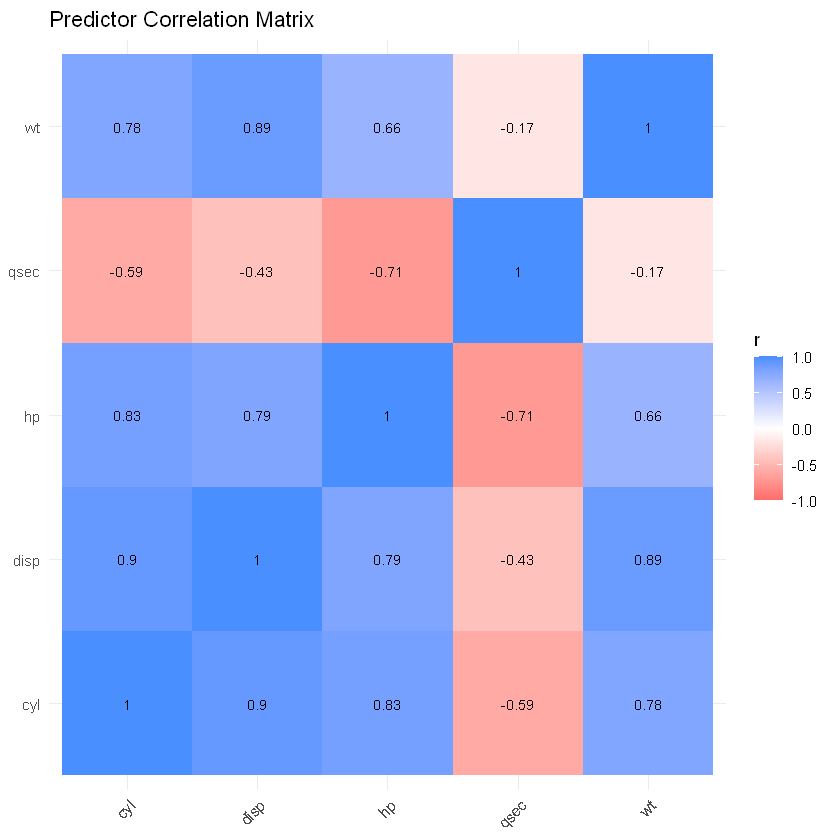

In [6]:
# ── Variance Inflation Factor (VIF) ──────────────────────────────────────────
car::vif(model_lm)
# VIF = 1:      no multicollinearity
# VIF 1-5:      acceptable
# VIF 5-10:     moderate — investigate
# VIF > 10:     severe — model coefficients are unstable

# ── Correlation matrix of predictors ─────────────────────────────────────────
mtcars %>%
  select(wt, hp, cyl) %>%
  cor()
# Correlations > |0.8| between predictors are a warning sign

# ── Visual: correlation heatmap ───────────────────────────────────────────────
mtcars %>%
  select(wt, hp, cyl, disp, qsec) %>%
  cor() %>%
  as.data.frame() %>%
  rownames_to_column("var1") %>%
  pivot_longer(-var1, names_to = "var2", values_to = "r") %>%
  ggplot(aes(x = var1, y = var2, fill = r)) +
  geom_tile() +
  geom_text(aes(label = round(r, 2)), size = 3) +
  scale_fill_gradient2(low = "#ff6b6b", mid = "white", high = "#4a8fff",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Predictor Correlation Matrix",
       x = NULL, y = NULL) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

---

## 5. Influential Observations

Three related concepts:
- **Outlier:** observation with a large residual (unexpected response given predictors)
- **High leverage:** observation with unusual predictor values (far from the center of the predictor space)
- **Influential:** observation that substantially changes model coefficients when removed — requires both leverage and a large residual

Influential observations (Cook's d > 4/n):
Chrysler Imperial    Toyota Corolla 
        0.3316313         0.1694339 

High leverage observations (h > 2(p+1)/n):
Maserati Bora 
    0.4635658 

Large standardized residuals (|z| > 2):
Chrysler Imperial          Fiat 128    Toyota Corolla 
         2.075289          2.316677          2.475079 


No Studentized residuals with Bonferroni p < 0.05
Largest |rstudent|:
               rstudent unadjusted p-value Bonferroni p
Toyota Corolla 2.749837           0.010508      0.33625

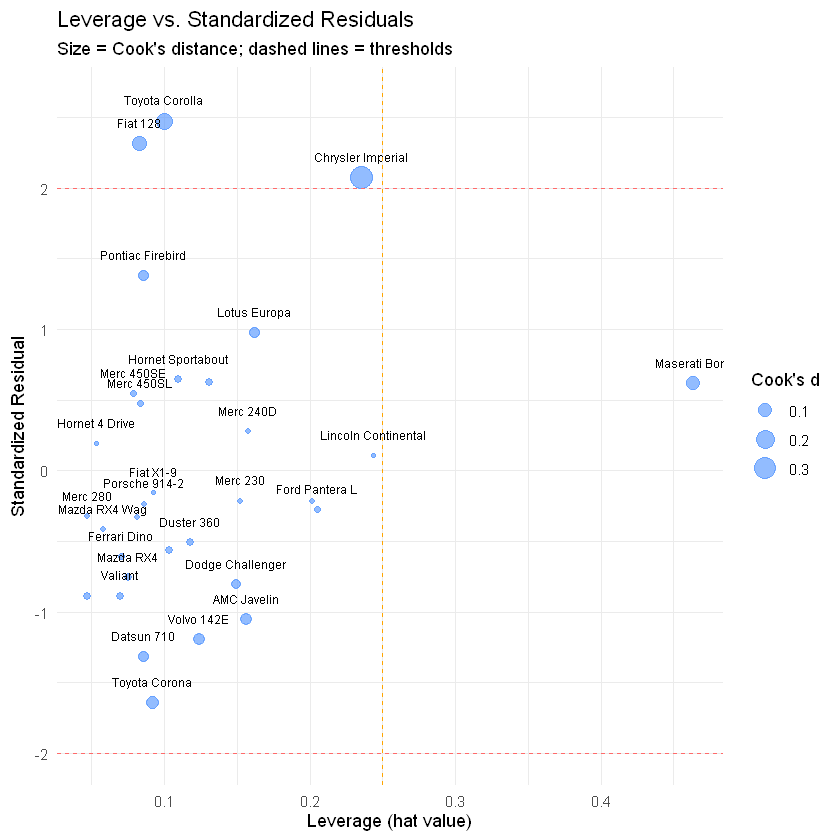

In [7]:
# ── Cook's distance ───────────────────────────────────────────────────────────
# Measures how much all fitted values change when observation i is removed
cooksd <- cooks.distance(model_lm)
threshold_4n <- 4 / nrow(mtcars)  # rule of thumb: 4/n

cat("Influential observations (Cook's d > 4/n):\n")
print(cooksd[cooksd > threshold_4n])

# ── Leverage (hat values) ─────────────────────────────────────────────────────
# High leverage: h_ii > 2(p+1)/n where p = number of predictors
p <- length(coef(model_lm)) - 1
leverage_threshold <- 2 * (p + 1) / nrow(mtcars)
hat_vals <- hatvalues(model_lm)
cat("\nHigh leverage observations (h > 2(p+1)/n):\n")
print(hat_vals[hat_vals > leverage_threshold])

# ── Standardized residuals ────────────────────────────────────────────────────
std_resid <- rstandard(model_lm)
cat("\nLarge standardized residuals (|z| > 2):\n")
print(std_resid[abs(std_resid) > 2])

# ── Bonferroni outlier test ───────────────────────────────────────────────────
# Tests whether the most extreme residual is a significant outlier
# after Bonferroni correction for multiple testing
car::outlierTest(model_lm)

# ── Bubble plot: leverage vs. residual, sized by Cook's d ────────────────────
mtcars_aug %>%
  mutate(label = rownames(mtcars)) %>%
  ggplot(aes(x = .hat, y = .std.resid, size = .cooksd, label = label)) +
  geom_point(alpha = 0.6, color = "#4a8fff") +
  geom_text(size = 2.5, nudge_y = 0.15, check_overlap = TRUE) +
  geom_hline(yintercept = c(-2, 2), linetype = "dashed", color = "#ff6b6b") +
  geom_vline(xintercept = leverage_threshold, linetype = "dashed", color = "orange") +
  labs(title = "Leverage vs. Standardized Residuals",
       subtitle = "Size = Cook's distance; dashed lines = thresholds",
       x = "Leverage (hat value)",
       y = "Standardized Residual",
       size = "Cook's d") +
  theme_minimal()

### Handling Influential Observations

> **Do not automatically remove influential observations.** First investigate why they are influential.

In [8]:
# ── Sensitivity analysis: fit with and without influential points ──────────────
# Identify the most influential observation
most_influential <- which.max(cooksd)
cat("Most influential observation:", rownames(mtcars)[most_influential], "\n")

# Fit model without it
model_without <- lm(mpg ~ wt + hp + cyl,
                    data = mtcars[-most_influential, ])

# Compare coefficients
comparison <- data.frame(
  term      = names(coef(model_lm)),
  full_data = round(coef(model_lm), 3),
  removed   = round(coef(model_without), 3),
  change_pct = round((coef(model_without) - coef(model_lm)) / abs(coef(model_lm)) * 100, 1)
)
print(comparison)
# Large changes (> 20%) in key coefficients warrant investigation and reporting

# Best practice:
# 1. Report results from the full model
# 2. Note that results are robust (or not) to removal of influential points
# 3. Never silently remove observations without justification

Most influential observation: Chrysler Imperial 
                   term full_data removed change_pct
(Intercept) (Intercept)    38.752  39.474        1.9
wt                   wt    -3.167  -3.863      -22.0
hp                   hp    -0.018  -0.021      -17.4
cyl                 cyl    -0.942  -0.652       30.7


---

## 6. Comprehensive Check with `performance`

The `performance` package provides an integrated dashboard of all key diagnostics in one call.

,AIC,AICc,BIC,R2,R2_adjusted,RMSE,Sigma
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,155.4766,157.7843,162.8053,0.84315,0.8263446,2.349338,2.511548


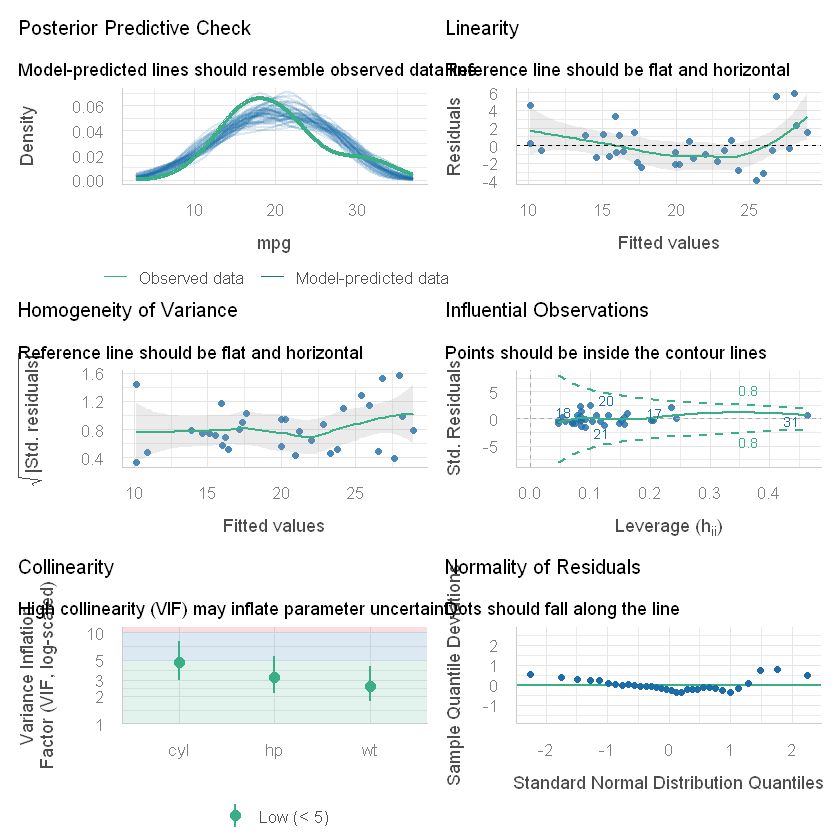

In [9]:
# ── Full model check ─────────────────────────────────────────────────────────
performance::check_model(model_lm)
# Generates a multi-panel diagnostic figure covering:
# posterior predictive check, linearity, homoscedasticity,
# influential observations, multicollinearity, normality of residuals

# ── Model performance metrics ─────────────────────────────────────────────────
performance::model_performance(model_lm)
# Returns: AIC, BIC, R², adjusted R², RMSE, sigma

---

## 7. Diagnostics for GLMs (Logistic, Poisson, etc.)

Standard residual plots are less interpretable for GLMs because residuals are not normally distributed by design. Use **DHARMa** for simulation-based residual diagnostics — see `03_mixed_effects_models/glmm_diagnostics.ipynb` for full coverage.

Warning message:
"package 'DHARMa' was built under R version 4.4.3"
Registered S3 method overwritten by 'lme4':
  method           from
  na.action.merMod car 

This is DHARMa 0.4.7. For overview type '?DHARMa'. For recent changes, type news(package = 'DHARMa')



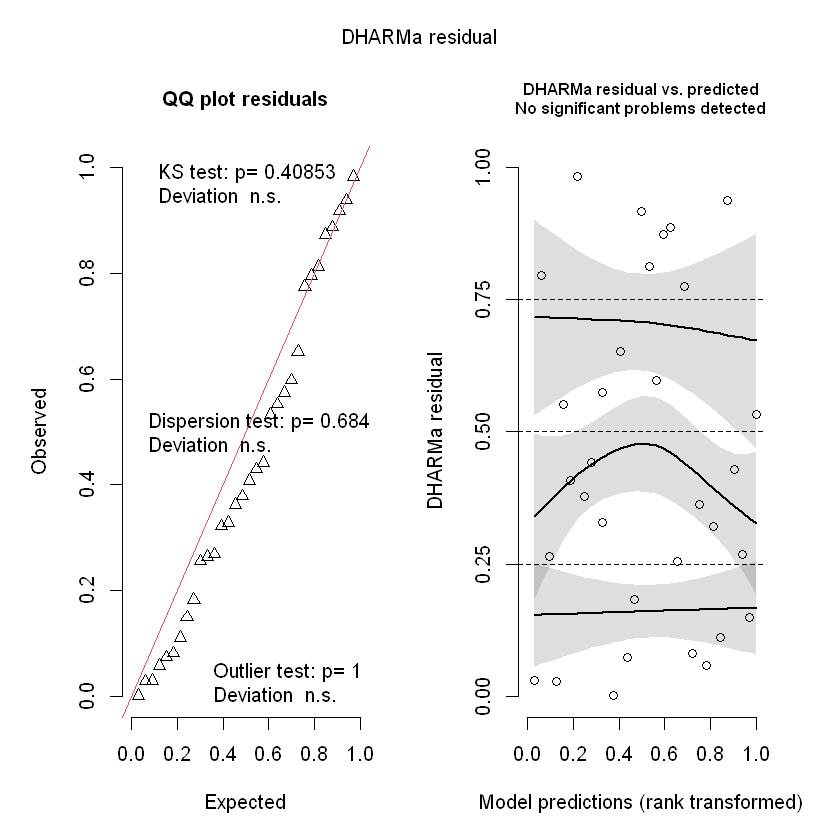


	Exact one-sample Kolmogorov-Smirnov test

data:  simulationOutput$scaledResiduals
D = 0.15213, p-value = 0.4085
alternative hypothesis: two-sided


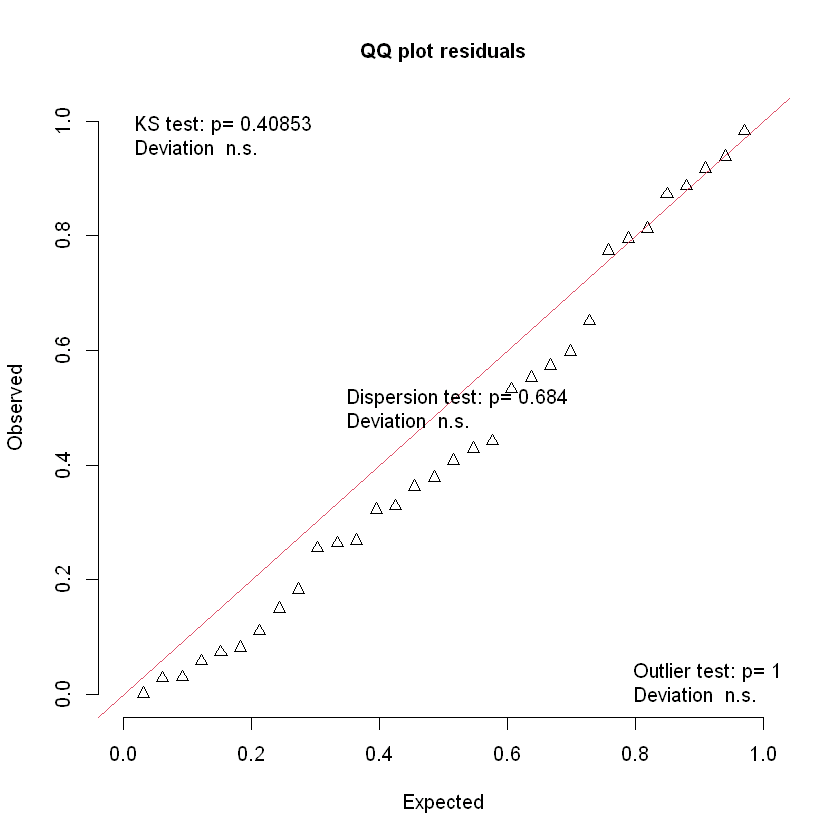


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 1.1203, p-value = 0.684
alternative hypothesis: two.sided


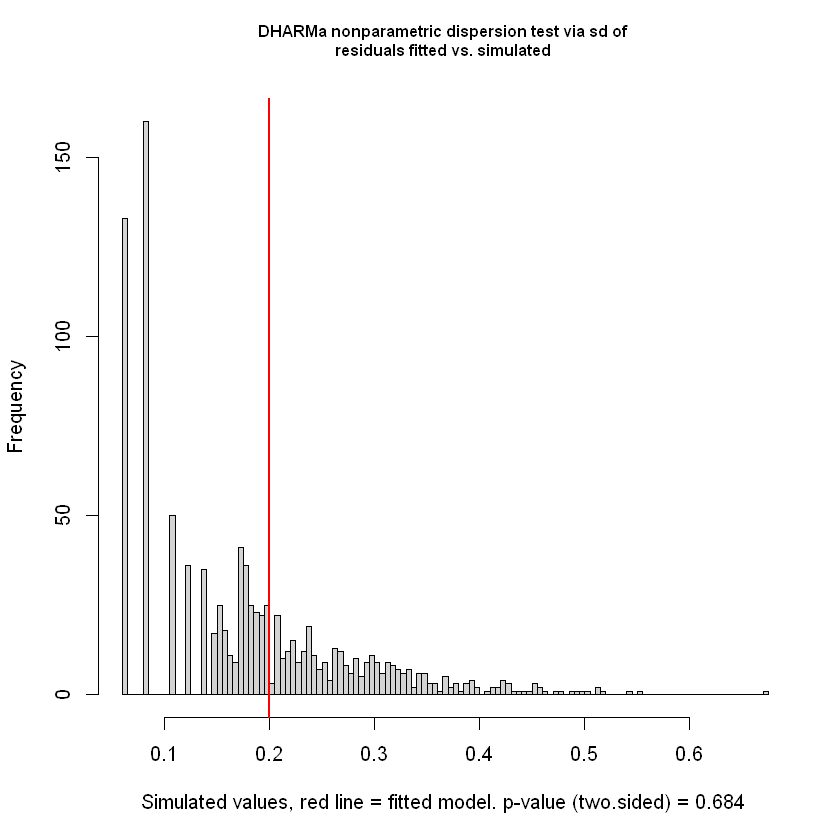


	DHARMa bootstrapped outlier test

data:  sim_resid
outliers at both margin(s) = 0, observations = 32, p-value = 1
alternative hypothesis: two.sided
 percent confidence interval:
 0 0
sample estimates:
outlier frequency (expected: 0 ) 
                               0 


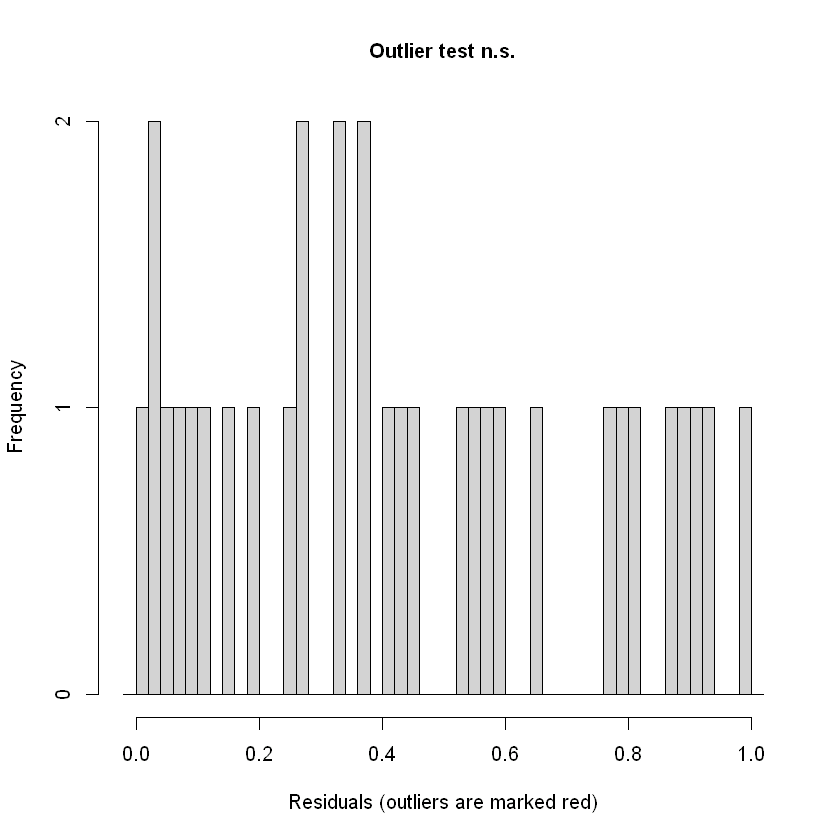

In [10]:
# ── DHARMa: simulation-based residuals for GLMs ───────────────────────────────
library(DHARMa)

# Fit a GLM for illustration
model_glm <- glm(am ~ wt + hp, data = mtcars, family = binomial)

# Simulate residuals
sim_resid <- DHARMa::simulateResiduals(model_glm, n = 1000)

# Plot: uniform distribution of residuals = good fit
plot(sim_resid)
# Left plot: QQ plot — points on diagonal = good
# Right plot: residuals vs. fitted — no pattern = good

# Formal tests
DHARMa::testUniformity(sim_resid)     # overall uniformity
DHARMa::testDispersion(sim_resid)     # over/underdispersion
DHARMa::testOutliers(sim_resid)       # outliers

---

## Common Pitfalls

**1. Skipping diagnostics entirely**  
The most common mistake. A significant p-value from a model with violated assumptions is not trustworthy. Always run diagnostics before reporting results.

**2. Testing normality on raw data instead of residuals**  
The normality assumption applies to model *residuals*, not the response variable. A skewed response variable can produce perfectly normal residuals if the model is well-specified.

**3. Automatically removing influential observations**  
Influential observations are not automatically errors. They may be the most scientifically interesting data points. Investigate first, then decide; always report both analyses if you remove any observations.

**4. Confusing high leverage with influence**  
An observation can have high leverage (unusual predictor values) without being influential if its residual is small. Influence requires both high leverage and a poor fit.

**5. Using standard lm diagnostics for GLMs**  
For logistic, Poisson, and other GLMs, standard residual plots are misleading. Use DHARMa simulation-based residuals instead.

**6. Treating the 4/n Cook's distance rule as a hard threshold**  
Rules of thumb (4/n, Cook's d > 1) are starting points for investigation, not automatic grounds for removal. Use them to flag observations for closer examination.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*